In [97]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from  torch.utils.data import DataLoader
import torchvision.datasets as ds
import os 
from tqdm import tqdm 

In [103]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.datasets as ds

transform = transforms.ToTensor()

dataset = ds.MNIST(root="./data", train=True, download=True, transform=transform)

batch_size = 64
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

for inputs, targets in dataloader: 
    print(inputs.shape)   
    print(targets.shape)  
    break


torch.Size([64, 1, 28, 28])
torch.Size([64])


we need encoder decoder and we need to define the forward with sampling and loss

In [ ]:
class VAE(nn.Module): 
    def __init__(self, d_in = 784, z = 128 ):
        super().__init__() 
        self.encoder = nn.Sequential(
            nn.Linear(d_in, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4,  2*z),
        )
        self.decoder = nn.Sequential(
            nn.Linear(z, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in*4),
            nn.GELU(),
            nn.Linear(d_in*4, d_in),
            nn.Sigmoid()

        )

        self.d_in = d_in
        self.z = z


    def encode(self, x):
        return self.encoder(x)
    def decode(self, x):
        return self.decoder(x)
    def forward(self, x):
        x_encoded = self.encode(x)
        meus, log_vars = torch.chunk(x_encoded, 2 , dim =-1)
        sigmas = torch.exp(0.5* log_vars)
        eps = torch.randn_like(sigmas)
        z = meus + eps * sigmas 
        return self.decoder(z), meus, sigmas, log_vars

the loss is reconstruction err +  KL (q || p) 

In [118]:
x = torch.randn(size = (12, 784))
model = VAE()
x_hat, meus, sigmas, log_vars = model(x)



In [119]:
optimizer = torch.optim.AdamW(params = model.parameters() , lr =5e-5)

In [ ]:

EPOCHS = 1

for i in tqdm(range(EPOCHS)):
    total_loss = 0
    model.train()
    for x, _ in dataloader:
        x = x.flatten(1)
        x_hat, meus, sigmas, log_vars = model(x)
        
        kl_loss = - 0.5 * (1+log_vars - meus**2 -sigmas**2 ).sum(dim =-1).mean(dim = 0)
        recon_loss = F.mse_loss(x_hat, x).sum(dim = -1).mean(dim = 0)
        loss = recon_loss + kl_loss
  

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        
        # Add to total loss (.item() pulls the float out of the PyTorch tensor)
        total_loss += loss.item()
        
    avg_loss = total_loss / len(dataloader)
    
    print(f"Epoch {i+1} | Average Loss: {avg_loss:.4f}")
    print(f"Samples covered: {len(dataloader)}")



  0%|          | 0/1 [00:00<?, ?it/s]

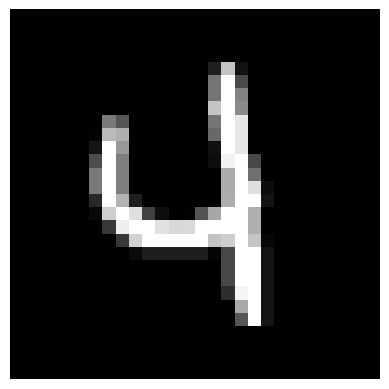

In [124]:
import matplotlib.pyplot as plt
import torch
def show_tensor_image(tensor_img):
    # 1. Pull tensor from GPU memory and detach from the computation graph
    img = tensor_img.detach().cpu()

    # 2. CASE A: If you used transforms.Normalize((0.5,), (0.5,)) during loading,
    # un-normalize back to [0, 1] by multiplying by std and adding mean:
    # img = img * 0.5 + 0.5

    # 3. CASE B: If your decoder ends with a Sigmoid activation, clamp to [0, 1] safety boundary
    img = torch.clamp(img, 0.0, 1.0)

    # 4. Reshape back from a flattened vector (e.g., 784) to an image shape (e.g., 28x28)
    # If using RGB data, use (3, 28, 28)
    img = img.view(28, 28)

    # 5. Plot using matplotlib
    plt.imshow(img.numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

for x, _ in dataloader:
        x = x.flatten(1)
        show_tensor_image(x[2])
        break
